<a href="https://colab.research.google.com/github/LisaChenn/RFML/blob/test/MLRF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
import json
import torch

DATA_DIR = "/content/drive/MyDrive/MLData"

train_path = os.path.join(DATA_DIR, "train.pt")
val_path = os.path.join(DATA_DIR, "val.pt")
test_path = os.path.join(DATA_DIR, "test.pt")
map_path = os.path.join(DATA_DIR, "voltage_map.json")

with open(map_path, "r") as f:
    voltage_map = json.load(f)

train_data = torch.load(train_path, map_location="cpu")
val_data = torch.load(val_path, map_location="cpu")
test_data = torch.load(test_path, map_location="cpu")

print("Loaded successfully.")
print(train_data.keys())

Loaded successfully.
dict_keys(['rx', 'tx', 'label', 'amp', 'voltage'])


In [ ]:
import os
import json
import torch

train_path = os.path.join(DATA_DIR, "train.pt")
val_path = os.path.join(DATA_DIR, "val.pt")
test_path = os.path.join(DATA_DIR, "test.pt")
map_path = os.path.join(DATA_DIR, "voltage_map.json")

with open(map_path, "r") as f:
    voltage_map = json.load(f)

train_data = torch.load(train_path, map_location="cpu")
val_data = torch.load(val_path, map_location="cpu")
test_data = torch.load(test_path, map_location="cpu")

In [ ]:
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import argparse
import umap

# Settings
torch.backends.cudnn.benchmark = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 256
EPOCHS = 40
LR = 1e-3
OUTPUT_DIR = "/content/drive/MyDrive/MLData/results_v7FixedIQ" #This is the folder where the Images + Model will be saved to
SEGMENT_LENGTH = 256
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load voltage map that we created when we split the dataset into Train test Val
with open("/content/drive/MyDrive/MLData/voltage_map.json", "r") as f:
    voltage_map = json.load(f)

id_to_voltage = {v: k for k, v in voltage_map.items()}



In [ ]:
# Dataset
class IQDataset(Dataset):
    def __init__(self, path):
        data = torch.load(path)
        self.rx = data["rx"]
        self.tx = data["tx"]
        self.labels = data["label"]
        self.amps = data["amp"]
        self.voltages = data["voltage"]

    def __len__(self):
        return len(self.rx)

    def __getitem__(self, idx):
        return self.rx[idx], self.tx[idx], self.labels[idx], self.amps[idx], self.voltages[idx]



In [ ]:
# Model
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv1d(2, 32, kernel_size=5, stride=2, padding=2),   # 1024 -> 512
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),  # 512 -> 256
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2), # 256 -> 128
            nn.BatchNorm1d(128),
            nn.ReLU(),
        )

        self.latent_pool = nn.AdaptiveAvgPool1d(1)
        self.latent_fc = nn.Linear(128, latent_dim)

        self.expand_fc = nn.Linear(latent_dim, 128 * 128)

        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(128, 64, kernel_size=4, stride=2, padding=1),  # 128 -> 256
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.ConvTranspose1d(64, 32, kernel_size=4, stride=2, padding=1),   # 256 -> 512
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.ConvTranspose1d(32, 2, kernel_size=4, stride=2, padding=1),    # 512 -> 1024
        )

    def encode(self, x):
        z = self.encoder(x)                  # [B, 128, 128]
        z = self.latent_pool(z).squeeze(-1) # [B, 128]
        z = self.latent_fc(z)               # [B, latent_dim]
        return z

    def decode(self, z):
        x = self.expand_fc(z)               # [B, 128*128]
        x = x.view(-1, 128, 128)            # [B, 128, 128]
        x = self.decoder(x)                 # [B, 2, 1024]
        return x

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z)


In [ ]:
def plot_error_histogram(errors, labels):
    normal_errors = errors[labels == 0]
    anomaly_errors = errors[labels == 1]

    plt.figure(figsize=(8, 5))
    plt.hist(normal_errors, bins=60, alpha=0.6, label="Normal")
    plt.hist(anomaly_errors, bins=60, alpha=0.6, label="Anomaly")
    plt.xlabel("Reconstruction MSE")
    plt.ylabel("Count")
    plt.title("Reconstruction Error Distribution")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# Training
def train(model, train_loader, val_loader):
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.MSELoss()
    scaler = torch.amp.GradScaler('cuda')

    best_val_loss = float("inf")
    patience = 5
    patience_counter = 0

    for epoch in range(EPOCHS):
        model.train()
        train_total, train_count = 0.0, 0

        for rx, tx, _, _, _ in train_loader:
            rx, tx = rx.to(DEVICE), tx.to(DEVICE)
            optimizer.zero_grad()

            with torch.amp.autocast('cuda'):
                out = model(rx)
                loss = criterion(out, tx)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_total += loss.item() * rx.size(0)
            train_count += rx.size(0)

        train_loss = train_total / train_count

        model.eval()
        val_total, val_count = 0.0, 0
        with torch.no_grad():
            for rx, tx, _, _, _ in val_loader:
                rx, tx = rx.to(DEVICE), tx.to(DEVICE)

                with torch.amp.autocast('cuda'):
                    out = model(rx)
                    loss = criterion(out, tx)

                val_total += loss.item() * rx.size(0)
                val_count += rx.size(0)

        val_loss = val_total / val_count
        print(f"Epoch {epoch+1:02d} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "best_model.pt"))
        else:
            patience_counter += 1
            print(f"EarlyStopping counter: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break


In [ ]:
def choose_threshold_from_normal(errors, percentile=95):
    return np.percentile(errors, percentile)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def evaluate_anomaly_scores(errors, labels, threshold):
    preds = (errors > threshold).astype(int)

    print("Threshold:", threshold)
    print("\nConfusion Matrix:")
    print(confusion_matrix(labels, preds))

    print("\nClassification Report:")
    print(classification_report(labels, preds, digits=4))

    try:
        auc = roc_auc_score(labels, errors)
        print("\nROC-AUC:", auc)
    except Exception as e:
        print("ROC-AUC could not be computed:", e)

In [ ]:
def compute_reconstruction_errors(model, loader):
    model.eval()
    errors = []
    labels = []
    amps = []
    voltages = []

    with torch.no_grad():
        for rx, tx, label, amp, voltage in loader:
            rx = rx.to(DEVICE)
            tx = tx.to(DEVICE)

            with torch.amp.autocast('cuda'):
                out = model(rx)

            # Per-sample MSE over channel and time dimensions
            batch_errors = torch.mean((out - tx) ** 2, dim=(1, 2))

            errors.extend(batch_errors.cpu().numpy())
            labels.extend(label.numpy())
            amps.extend(amp.numpy())
            voltages.extend(voltage.numpy())

    return np.array(errors), np.array(labels), np.array(amps), np.array(voltages)

In [ ]:

# Latent extraction
def extract_latent(model, loader):
    model.eval()
    latents, labels, amps, voltages = [], [], [], []
    with torch.no_grad():
        for rx, _, label, amp, voltage in loader:
            rx = rx.to(DEVICE)
            z = model.encoder(rx)
            z = torch.mean(z, dim=2)

            latents.append(z.cpu().numpy())
            labels.extend(label.numpy())
            amps.extend(amp.numpy())
            voltages.extend(voltage.numpy())

    return np.vstack(latents), np.array(labels), np.array(amps), np.array(voltages)

def plot_iq_segment(rx, tx, reconstructed, segment=SEGMENT_LENGTH, save_path=None, title="IQ Segment"):
    rx = rx[:, :segment].cpu().numpy()
    tx = tx[:, :segment].cpu().numpy()
    rec = reconstructed[:, :segment].detach().cpu().numpy()
    plt.figure(figsize=(12,4))

    # Rx
    plt.plot(rx[0], label="RX I", color="blue")
    plt.plot(rx[1], label="RX Q", color="cyan")

    # Tx
    plt.plot(tx[0], '--', label="TX I", color="green")
    plt.plot(tx[1], '--', label="TX Q", color="lime")

    # Recon
    plt.plot(rec[0], '-.', label="Recon I", color="orange")
    plt.plot(rec[1], '-.', label="Recon Q", color="red")
    plt.legend(fontsize=8)
    plt.title(title)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path)
    plt.show() # Feel free to comment this out if you dont want to see it every time

# UMAP plotting
def plot_umap(test_emb, labels, amps, voltages):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    colors = np.where(labels == 1, "red", "blue")
    axes[0].scatter(test_emb[:, 0], test_emb[:, 1], c=colors, s=6)
    axes[0].set_title("Anomaly (Red)")

    amp_colors = ["blue", "green", "orange", "purple", "red", "brown"]
    for a in np.unique(amps):
        idx = amps == a
        axes[1].scatter(test_emb[idx, 0], test_emb[idx, 1],
                        s=5, c=amp_colors[a], label=f"A{a+1}")
    axes[1].legend(markerscale=3)
    axes[1].set_title("Amplifier Groups")

    for v in np.unique(voltages):
        idx = voltages == v
        voltage_value = float(id_to_voltage[int(v)])
        axes[2].scatter(test_emb[idx, 0], test_emb[idx, 1],
                        s=5, label=f"{voltage_value:.2f} V")

    axes[2].legend(markerscale=3)
    axes[2].set_title("Voltage")

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "umap_voltage.png"))
    plt.show()

# Sample plotting
def plot_samples_for_chunks(ds, model, num_samples=6):
    indices = np.random.choice(len(ds), num_samples, replace=False)
    model.eval()

    for idx in indices:
        rx, tx, label, amp, voltage = ds[idx]
        with torch.no_grad():
            reconstructed = model(rx.unsqueeze(0).to(DEVICE)).squeeze(0)

        real_voltage = float(id_to_voltage[int(voltage)])
        plot_iq_segment(
            rx,
            tx,
            reconstructed,
            segment=SEGMENT_LENGTH,
            save_path=os.path.join(OUTPUT_DIR, f"chunk_{idx}.png"),
            title=f"Idx {idx} | Label {label} | Amp {amp} | {real_voltage:.2f}V")



In [ ]:
LOAD_MODEL = False

train_ds = IQDataset(os.path.join(DATA_DIR, "train.pt"))
val_ds = IQDataset(os.path.join(DATA_DIR, "val.pt"))
test_ds = IQDataset(os.path.join(DATA_DIR, "test.pt"))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


model = ConvAutoencoder(latent_dim=32).to(DEVICE)

if LOAD_MODEL and os.path.exists(os.path.join(OUTPUT_DIR, "best_model.pt")):
    model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, "best_model.pt"), map_location=DEVICE))
    print("Loaded model.")
else:
    print("Training...")
    train(model, train_loader, val_loader)



Training...
Epoch 01 | Train: 0.007951 | Val: 0.003158
Epoch 02 | Train: 0.000414 | Val: 0.003304
EarlyStopping counter: 1/5
Epoch 03 | Train: 0.000296 | Val: 0.000812
Epoch 04 | Train: 0.000226 | Val: 0.000452
Epoch 05 | Train: 0.000179 | Val: 0.000352
Epoch 06 | Train: 0.000132 | Val: 0.001719
EarlyStopping counter: 1/5
Epoch 07 | Train: 0.000098 | Val: 0.000162
Epoch 08 | Train: 0.000069 | Val: 0.000153
Epoch 09 | Train: 0.000069 | Val: 0.000153
EarlyStopping counter: 1/5
Epoch 10 | Train: 0.000055 | Val: 0.000334
EarlyStopping counter: 2/5
Epoch 11 | Train: 0.000057 | Val: 0.000212
EarlyStopping counter: 3/5
Epoch 12 | Train: 0.000054 | Val: 0.000408
EarlyStopping counter: 4/5
Epoch 13 | Train: 0.000061 | Val: 0.000139
Epoch 14 | Train: 0.000038 | Val: 0.000254
EarlyStopping counter: 1/5
Epoch 15 | Train: 0.000036 | Val: 0.000521
EarlyStopping counter: 2/5
Epoch 16 | Train: 0.000033 | Val: 0.000105
Epoch 17 | Train: 0.000037 | Val: 0.000047
Epoch 18 | Train: 0.000028 | Val: 0.00002

In [ ]:
    plot_umap(test_emb, labels, amps, voltages)
    print("Plotting samples...")
    plot_samples_for_chunks(test_ds, model)

NameError: name 'test_emb' is not defined

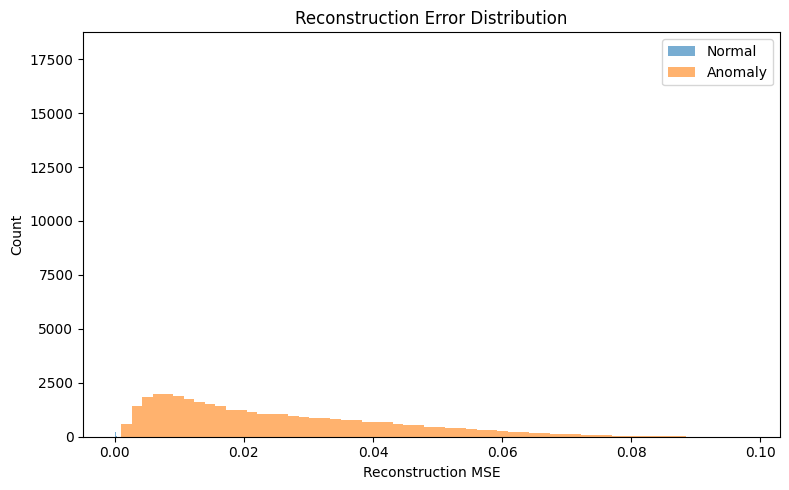

Threshold: 6.96299e-05

Confusion Matrix:
[[55462  2951]
 [    0 37050]]

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9495    0.9741     58413
           1     0.9262    1.0000    0.9617     37050

    accuracy                         0.9691     95463
   macro avg     0.9631    0.9747    0.9679     95463
weighted avg     0.9714    0.9691    0.9693     95463


ROC-AUC: 1.0


In [ ]:
val_errors, val_labels, _, _ = compute_reconstruction_errors(model, val_loader)
test_errors, test_labels, test_amps, test_voltages = compute_reconstruction_errors(model, test_loader)

threshold = choose_threshold_from_normal(val_errors[val_labels == 0], percentile=95)

plot_error_histogram(test_errors, test_labels)
evaluate_anomaly_scores(test_errors, test_labels, threshold)

In [ ]:
print(np.unique(test_labels, return_counts=True))

(array([0, 1]), array([58413, 37050]))


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

threshold = np.percentile(val_errors[val_labels == 0], 99)
preds = (test_errors > threshold).astype(int)

print("Threshold:", threshold)
print("\nConfusion Matrix:")
print(confusion_matrix(test_labels, preds))

print("\nClassification Report:")
print(classification_report(test_labels, preds, digits=4))

print("\nROC-AUC:", roc_auc_score(test_labels, test_errors))

Threshold: 0.00017120643

Confusion Matrix:
[[57821   592]
 [    0 37050]]

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9899    0.9949     58413
           1     0.9843    1.0000    0.9921     37050

    accuracy                         0.9938     95463
   macro avg     0.9921    0.9949    0.9935     95463
weighted avg     0.9939    0.9938    0.9938     95463


ROC-AUC: 1.0


In [ ]:

print("Extracting latents...")
train_latents, _, _, _ = extract_latent(model, train_loader)
test_latents, labels, amps, voltages = extract_latent(model, test_loader)


Extracting latents...


In [ ]:
from sklearn.preprocessing import StandardScaler
import umap
import numpy as np

scaler = StandardScaler()
train_latents_scaled = scaler.fit_transform(train_latents)
test_latents_scaled = scaler.transform(test_latents)

reducer = umap.UMAP(
    n_neighbors=10,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

reducer.fit(train_latents_scaled)
test_emb = reducer.transform(test_latents_scaled)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


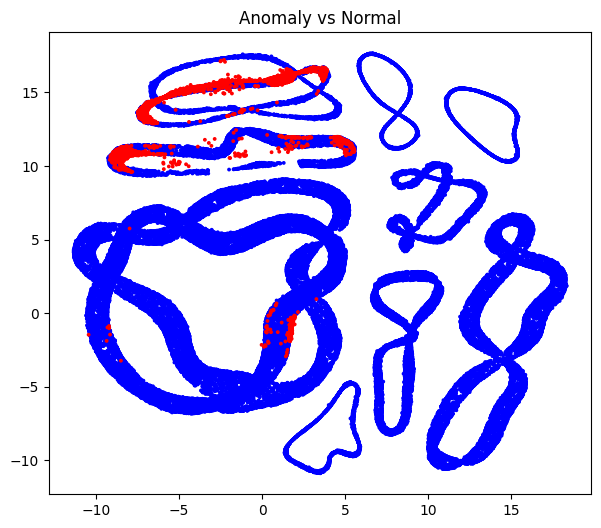

In [ ]:
colors = np.where(labels == 1, "red", "blue")
plt.figure(figsize=(7,6))
plt.scatter(test_emb[:,0], test_emb[:,1], c=colors, s=3)
plt.title("Anomaly vs Normal")
plt.show()

Plotting samples...


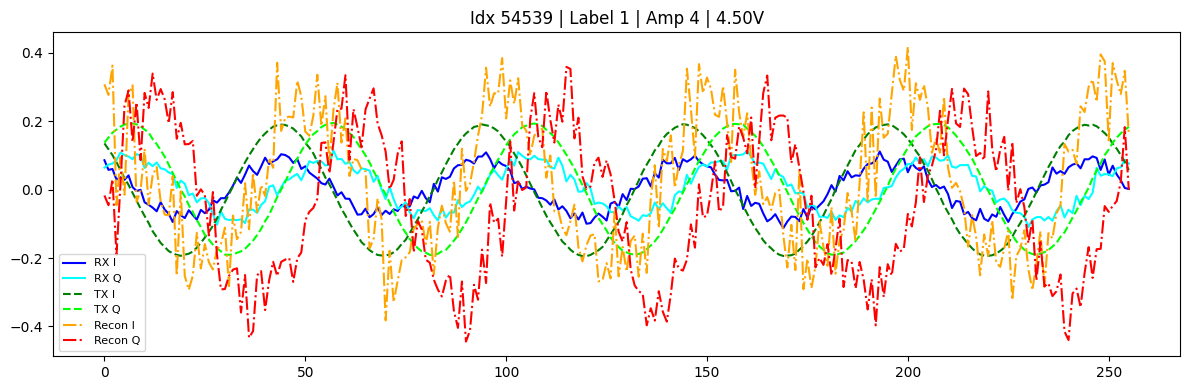

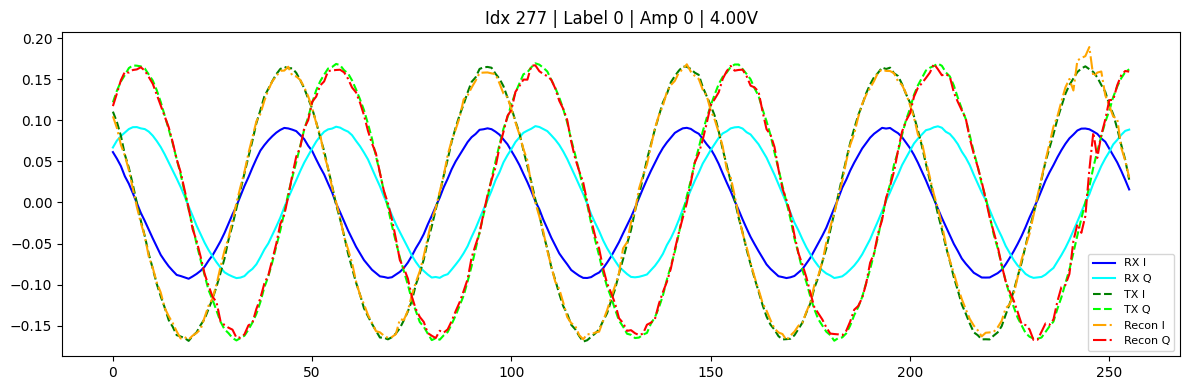

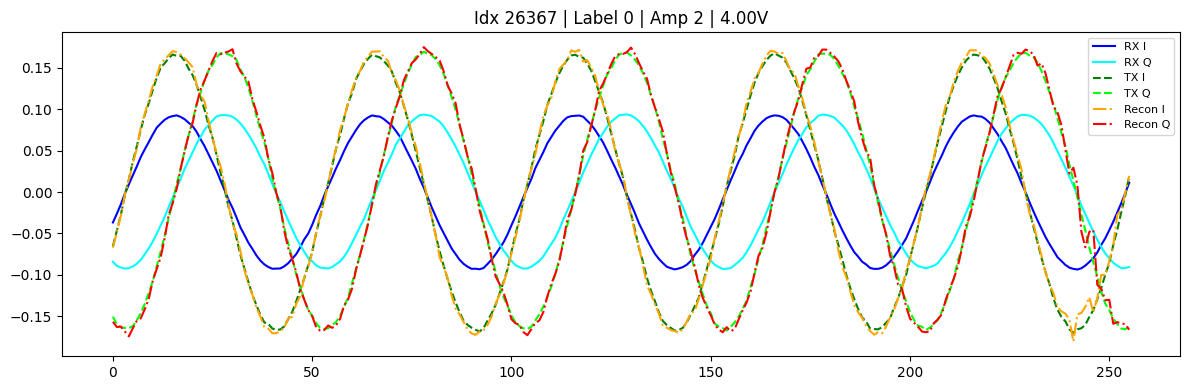

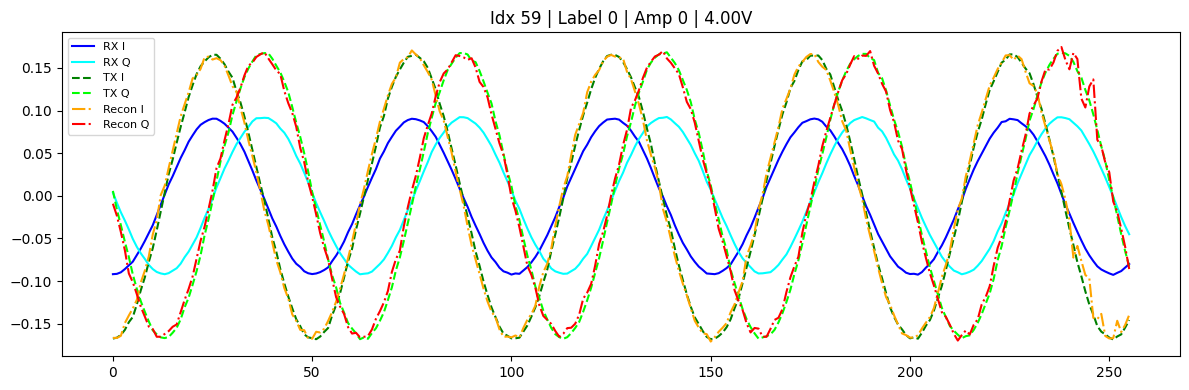

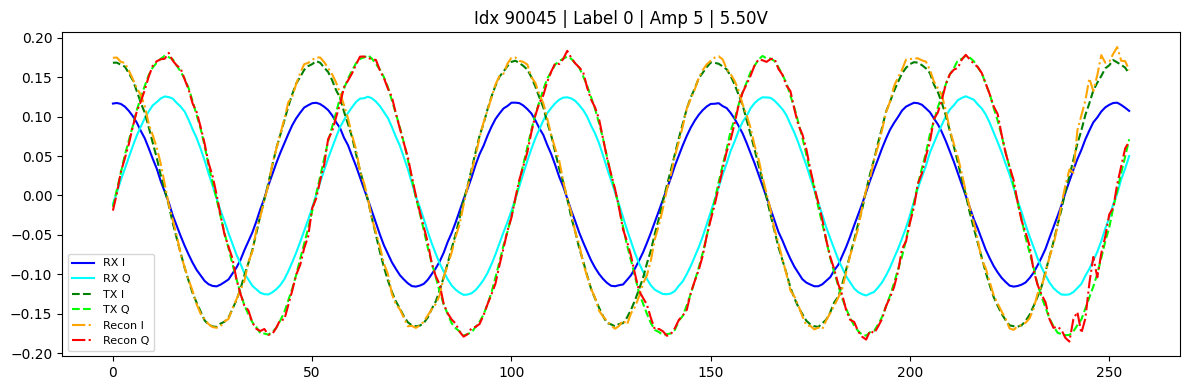

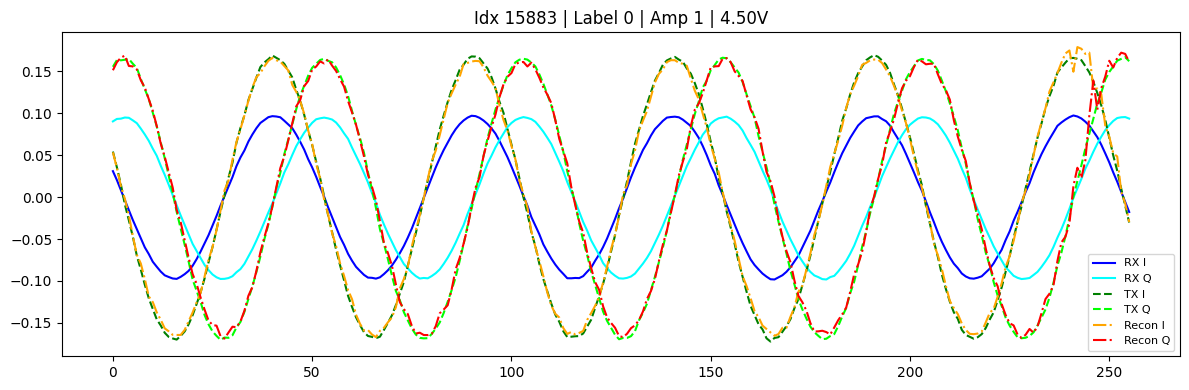

In [ ]:

print("Plotting samples...")
plot_samples_for_chunks(test_ds, model)
